# Fig. 6B: Plot entropy variation across ping and asymptotic lines

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm

from infotaxis import one_target

In [2]:
path_main = Path("../simulations")

path_data = path_main / "20251028"
path_summary = path_main / "20251028_summary"

path_fig = Path("../figs")

In [3]:
def load_ph(search_type, cr, br, pm):
    return xr.open_dataset(path_summary / f"{search_type}_cr{cr}_br{br}_pm{pm:.0e}_pfa{pm:.0e}_ph.nc")

In [4]:
def get_ping_cross_pmax_th(ds, p_max_th=0.95):    
    ping_cross_all = []
    for run in ds["run"].values:
        ping_cross_th = ds["p_max"].sel(run=run).dropna(dim="ping").values > p_max_th
        if ping_cross_th.sum() > 0:
            ping_cross = np.argwhere(ping_cross_th).min()
        else:
            ping_cross = 999
        ping_cross_all.append(int(ping_cross))
    return np.array(ping_cross_all)

In [5]:
cr_all = list(range(5, 16))
br = 1
pm = 0

In [6]:
run_number_cr = dict()
for cr in cr_all:    
    ds_infotaxis = load_ph("infotaxis", cr, br, pm)
    ping_cross_p_max_th_infotaxis = get_ping_cross_pmax_th(ds_infotaxis)

    folder = f"20251028_infotaxis_pmaxRepeat_canvasRadius{cr}_beamRadius{br}_pm{pm:.0e}_pfa{pm:.0e}"
    run_number =  np.argmax(ping_cross_p_max_th_infotaxis)+1 # +1 since argmax returns index (0-based)
                                                             # run number is 1-based
    nc_fname = f"infotaxis_{run_number:04d}.nc"
    run_number_cr[cr] = run_number

In [7]:
search_dict = None
param_echo = {
    str(1): {
        "pm_const": pm,
        "pfa_const": 0,
    },
}

In [8]:
delta_h_all = dict()
alpha_all = dict()
for cr in cr_all:

    oth = one_target.OneTargetHex(
        search_rule="infotaxis",
        canvas_radius=cr,
        beam_radius=[br],
        target_cube=(0, 0, 0),
        aim_start_cube=(-2, 3, -1),
        beam_radius_start=1,
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=search_dict
    )

    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha = grid_in_beam / grid_in_space
    delta_h = -alpha / np.log(2)

    delta_h_all[cr] = delta_h
    alpha_all[cr] = alpha

    print(f"cr={cr}: ")
    print(f" - grid_in_beam: {grid_in_beam}")
    print(f" - grid_in_space: {grid_in_space}")

cr=5: 
 - grid_in_beam: 7
 - grid_in_space: 91
cr=6: 
 - grid_in_beam: 7
 - grid_in_space: 127
cr=7: 
 - grid_in_beam: 7
 - grid_in_space: 169
cr=8: 
 - grid_in_beam: 7
 - grid_in_space: 217
cr=9: 
 - grid_in_beam: 7
 - grid_in_space: 271
cr=10: 
 - grid_in_beam: 7
 - grid_in_space: 331
cr=11: 
 - grid_in_beam: 7
 - grid_in_space: 397
cr=12: 
 - grid_in_beam: 7
 - grid_in_space: 469
cr=13: 
 - grid_in_beam: 7
 - grid_in_space: 547
cr=14: 
 - grid_in_beam: 7
 - grid_in_space: 631
cr=15: 
 - grid_in_beam: 7
 - grid_in_space: 721


In [9]:
delta_h_all

{5: np.float64(-0.11097654160684335),
 6: np.float64(-0.07951862430096648),
 7: np.float64(-0.059756599326761806),
 8: np.float64(-0.0465385497060956),
 9: np.float64(-0.037265185558017506),
 10: np.float64(-0.030510167027863275),
 11: np.float64(-0.025437947824238652),
 12: np.float64(-0.021532761804312888),
 13: np.float64(-0.01846227657444743),
 14: np.float64(-0.016004540865646188),
 15: np.float64(-0.014006747969795761)}

In [10]:
alpha_all

{5: 0.07692307692307693,
 6: 0.05511811023622047,
 7: 0.04142011834319527,
 8: 0.03225806451612903,
 9: 0.025830258302583026,
 10: 0.021148036253776436,
 11: 0.017632241813602016,
 12: 0.014925373134328358,
 13: 0.012797074954296161,
 14: 0.011093502377179081,
 15: 0.009708737864077669}

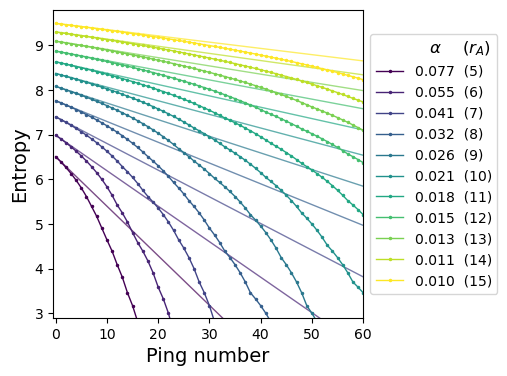

In [11]:
# Get colors from Spectral colormap
cmap = matplotlib.colormaps["viridis"]
colors = [cmap(c / (len(cr_all) - 1)) for c in range(len(cr_all))]

hline = [None]*len(cr_all)
fig,ax = plt.subplots(1, 1, figsize=(4,4))

for seq, cr in enumerate(cr_all):
    folder = f"20251028_infotaxis_pmaxRepeat_canvasRadius{cr}_beamRadius{br}_pm{pm:.0e}_pfa{pm:.0e}"
    run_number =  run_number_cr[cr]
    nc_fname = f"infotaxis_{run_number:04d}.nc"
    ds = xr.open_dataset(path_data / folder / nc_fname, engine="netcdf4")

    ping_h_last_before_0 = (ds["h_actual_all"].values > 0).sum()

    # slope of h_actual decrease    
    hline[seq], = plt.plot(
        ds["h_actual_all"].values[:ping_h_last_before_0],
        lw=1, color=colors[seq], alpha=1, marker=".", markersize=3
    )

    # approximate slope
    plt.plot(
        np.arange(0, 60, 0.1),
        ds["h_actual_all"].values[0]+delta_h_all[cr]*np.arange(0, 60, 0.1),
        color=colors[seq], lw=1, ls="-", alpha=0.7, 
    )

plt.legend(
    hline,
    [f"{aa:.3f}  ({cc:d})" for cc,aa in zip(cr_all, alpha_all.values())],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title=r"          $\alpha$    ($r_A$)",
    title_fontproperties=fm.FontProperties(weight="normal", size=12),
)
# plt.text(71, 9.1, r"$\alpha$", ha="center", fontsize=12)

plt.xlabel("Ping number", fontsize=14)
plt.ylabel("Entropy", fontsize=14)

plt.xlim(-0.5, 60)
plt.ylim(2.9, 9.8)
plt.show()

fig.savefig(path_fig / "fig_6B_entropy_decrease.png", dpi=300, bbox_inches="tight")